# Sumarização e avaliação de desempenho de diálogos de atendimento ao cliente pelo Twitter

- Compara resultados da sumarização com os modelos escolhidos

## Bibliotecas Python

In [1]:
import pandas as pd
import os
from rich import print
from typing import Tuple
import seaborn as sns
import random

import matplotlib.pyplot as plt

sns.set_palette('colorblind')

## Constantes

In [2]:
PATH_PROCESSED_DATASETS = f'../data/processed/'

os.listdir(PATH_PROCESSED_DATASETS)

['df_eval_qwen.csv',
 'df_metrics_google_t5.csv',
 'df_metrics_falconsai.csv',
 'df_metrics_qwen.csv',
 'df_eval_falconsai.csv',
 'df_eval_google_t5.csv']

## Join dos resultados

In [3]:
def get_results(model_name: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_metrics =  pd.read_csv(os.path.join(PATH_PROCESSED_DATASETS, f'df_metrics_{model_name}.csv'))
    df_eval = pd.read_csv(os.path.join(PATH_PROCESSED_DATASETS, f'df_eval_{model_name}.csv'))
    df_eval.rename(
        columns={
            'summary_pred': f'summary_pred_{model_name}'
        },
        inplace=True
    )
    df_eval[f'n_chars_summary_pred_{model_name}'] = df_eval[f'summary_pred_{model_name}'].apply(lambda x: len(x))
    df_eval[f'n_words_summary_pred_{model_name}'] = df_eval[f'summary_pred_{model_name}'].apply(lambda x: len(x.split(' ')))
    
    df_eval[f'n_chars_input'] = df_eval[f'inputs'].apply(lambda x: len(x))
    df_eval[f'n_words_input'] = df_eval[f'inputs'].apply(lambda x: len(x.split(' ')))

    return df_metrics, df_eval                             


In [4]:
df_metrics_t5, df_eval_t5  = get_results('google_t5')
df_metrics_falconsai, df_eval_falconsai = get_results('falconsai')
df_metrics_qwen, df_eval_qwenm,  = get_results('qwen')

## Resultados

### Métricas

In [5]:
df_metrics = pd.concat([df_metrics_t5, df_metrics_falconsai, df_metrics_qwen])
df_metrics.index = df_metrics.model
df_metrics.drop(columns='model', inplace=True)
df_metrics

,rouge1,rouge2,rougeL,rougeLsum
model,,,,
google-t5/t5-small,0.282673,0.129450,0.237122,0.237086
Falconsai/text_summarization,0.290346,0.130525,0.238652,0.238675
Qwen/Qwen2.5-0.5B-Instruct,0.228629,0.049508,0.171280,0.171325


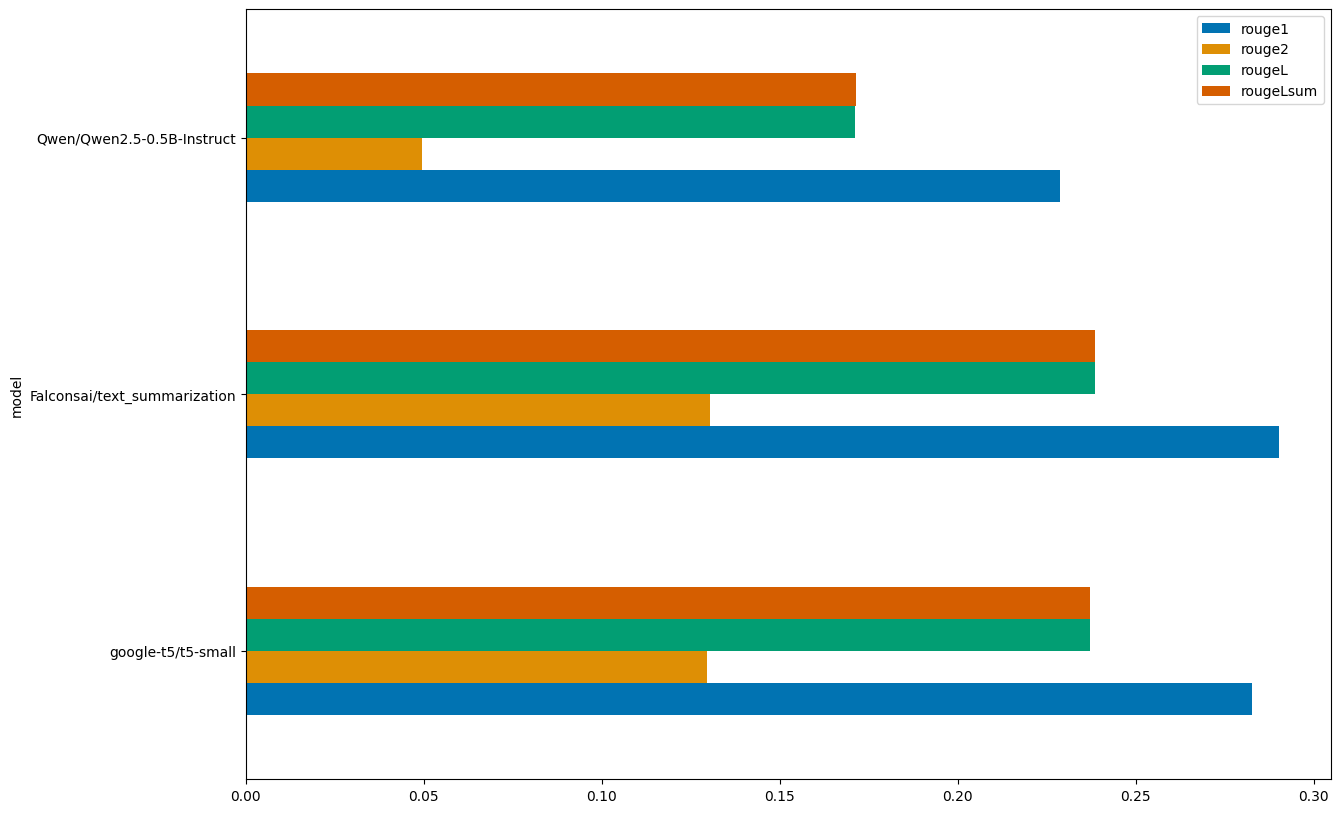

In [6]:
df_metrics.plot(kind='barh', figsize=(14, 10));

### Dataset de avaliação

In [7]:
df_eval_t5.head(1)

,conversation_id,tweet_ids,created_at_list,inputs,human_summary,elapsed_time,summary_pred_google_t5,n_chars_summary_pred_google_t5,n_words_summary_pred_google_t5,n_chars_input,n_words_input
0,b065262210783596c1fe79466b8f8985,"[87073, 87074, 87076]","{87073: Timestamp('2017-11-28 21:57:00+0000', ...",So neither my iPhone nor my Apple Watch are re...,Customer enquired about his Iphone and Apple w...,0 days 01:11:08,neither my iPhone nor my Apple Watch are recor...,195,32,377,59


In [8]:
cols_pred = ['summary_pred', 'elapsed_time']
cols = [col for col in df_eval_t5.columns.to_list() if not col.endswith('t5')]

df_evals = (
    df_eval_t5.merge(df_eval_falconsai, how='inner', on=cols)
        .merge(df_eval_qwenm, how='inner', on=cols)
)

df_evals.head(1)

,conversation_id,tweet_ids,created_at_list,inputs,human_summary,elapsed_time,summary_pred_google_t5,n_chars_summary_pred_google_t5,n_words_summary_pred_google_t5,n_chars_input,n_words_input,summary_pred_falconsai,n_chars_summary_pred_falconsai,n_words_summary_pred_falconsai,summary_pred_qwen,n_chars_summary_pred_qwen,n_words_summary_pred_qwen
0,b065262210783596c1fe79466b8f8985,"[87073, 87074, 87076]","{87073: Timestamp('2017-11-28 21:57:00+0000', ...",So neither my iPhone nor my Apple Watch are re...,Customer enquired about his Iphone and Apple w...,0 days 01:11:08,neither my iPhone nor my Apple Watch are recor...,195,32,377,59,Health doesn’t recognise either source anymore...,214,37,The user's iPhone and Apple Watch are not reco...,226,35


In [9]:
df_evals.describe()

,n_chars_summary_pred_google_t5,n_words_summary_pred_google_t5,n_chars_input,n_words_input,n_chars_summary_pred_falconsai,n_words_summary_pred_falconsai,n_chars_summary_pred_qwen,n_words_summary_pred_qwen
count,2327.000000,2327.000000,2327.000000,2327.000000,2327.000000,2327.00000,2327.000000,2327.000000
mean,194.370434,33.865492,526.827675,91.730984,250.519983,43.68844,163.067039,27.515256
std,46.821420,8.837476,212.312702,37.861480,65.507303,12.22157,102.658312,16.739535
min,93.000000,14.000000,90.000000,16.000000,97.000000,12.00000,20.000000,4.000000
25%,161.000000,28.000000,388.500000,67.000000,198.000000,34.00000,93.000000,16.000000
50%,187.000000,32.000000,505.000000,87.000000,243.000000,42.00000,127.000000,21.000000
75%,218.000000,39.000000,623.000000,109.000000,299.000000,52.00000,213.000000,35.000000
max,415.000000,76.000000,2187.000000,382.000000,458.000000,78.00000,581.000000,94.000000


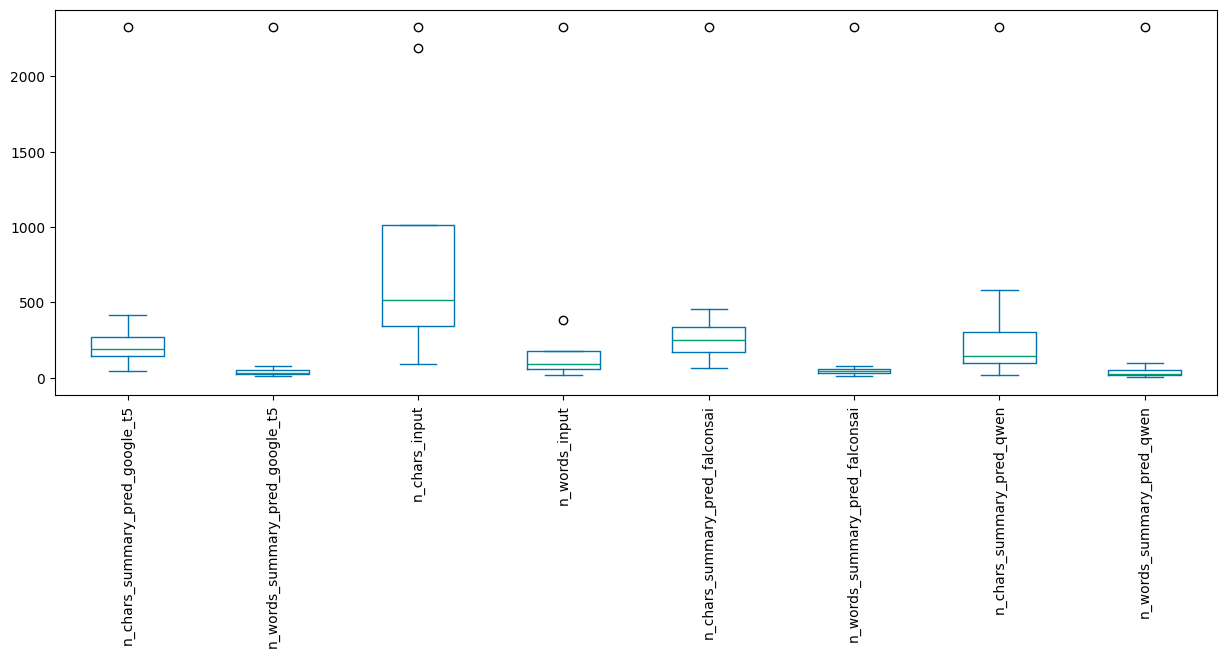

In [10]:
ax = df_evals.describe().plot(kind='box', figsize=(15, 5));
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);

In [11]:
df_evals_numeric = df_evals.select_dtypes('int64')
df_evals_numeric.head()

,n_chars_summary_pred_google_t5,n_words_summary_pred_google_t5,n_chars_input,n_words_input,n_chars_summary_pred_falconsai,n_words_summary_pred_falconsai,n_chars_summary_pred_qwen,n_words_summary_pred_qwen
0,195,32,377,59,214,37,226,35
1,212,34,315,47,229,38,172,30
2,193,33,572,89,269,47,242,41
3,163,28,407,75,144,21,152,26
4,131,23,264,42,150,25,107,18


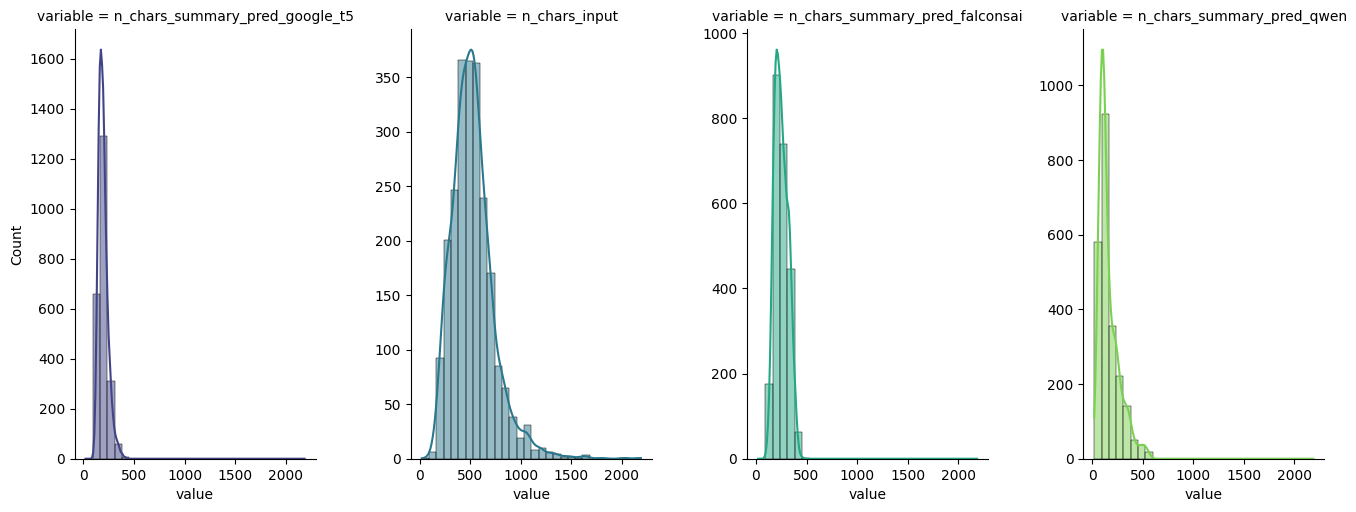

In [12]:
def displot_graph(df: pd.DataFrame, graph_name: str):
    g = sns.displot(
        df.melt(),
        x='value',
        col='variable',
        col_wrap=4,
        hue='variable',
        palette='viridis',
        bins=30,
        kde=True,
        height=2,        # ↑ tamanho de cada subplot
        aspect=1.1,      # ↑ largura proporcional
        facet_kws={'sharex': False, 'sharey': False},
        legend=False,
    )
    g.figure.set_size_inches(14, 8) 
    g.savefig(graph_name, dpi=100, bbox_inches='tight')


cols_char = [col for col in df_evals_numeric.columns if 'char' in col]
cols_words = [col for col in df_evals_numeric.columns if 'words' in col]

displot_graph(df=df_evals_numeric[cols_char], graph_name='../imgs/displot_graph_cols_char.png')

In [13]:
# displot_graph(df=df_evals_numeric[cols_words], graph_name='../imgs/displot_graph_cols_words.png')

### Comparando amostras

In [14]:
cols_summ = ['human_summary', 'summary_pred_google_t5', 'summary_pred_falconsai', 'summary_pred_qwen']
print(df_evals[cols_summ].iloc[0].to_dict())

{
    'human_summary': 'Customer enquired about his Iphone and Apple watch which is not showing his any 
steps/activity and health activities. Agent is asking to move to DM and look into it.',
    'summary_pred_google_t5': 'neither my iPhone nor my Apple Watch are recording my steps/activity. health doesn’t
recognise either source anymore for some reason. @AppleSupport My iPhone is on 11.1.2, and my watch is on 4.1.',
    'summary_pred_falconsai': 'Health doesn’t recognise either source anymore for some reason. To start, can you 
tell us the software versions your iPhone and Apple Watch are running? @AppleSupport My iPhone is on 11.1.2, and my
watch is on 4.1.',
    'summary_pred_qwen': "The user's iPhone and Apple Watch are not recording their step activity or activities, 
and Health is unable to recognize either source due to an unknown issue. They would benefit from investigating 
together with @AppleSupport."
}

In [15]:
idx = random.randint(0, df_evals.shape[0])

print(df_evals[cols_summ].iloc[idx].to_dict())

{
    'human_summary': 'Customer is complaining about missed boarding position. Agent informed that there are only 
able to issue the next available boarding position and there agents have the ability to offer upgrade boarding when
available within one hour of departure.',
    'summary_pred_google_t5': "@SouthwestAir U changed my flight, I lose boarding position A to C &amp; wouldn't 
let me $ for priority boarding during check in! @362896 Mike, in these situations, we're only able to issue the 
next available boarding position.",
    'summary_pred_falconsai': "@SouthwestAir U changed my flight, I lose boarding position A to C &amp; wouldn't 
let me $ for priority boarding during check in! CT @SouthwestAir I did but was told they just sold the last 
position right before me. Upgraded Boarding is popular &amp; sells out fast. Fingers crossed for next time; see you
onboard!",
    'summary_pred_qwen': 'The Southwest Air crew can upgrade your boarding position if you want to board later than
you were supposed to.'
}

In [16]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_evals.sample(2)

,conversation_id,tweet_ids,created_at_list,inputs,human_summary,elapsed_time,summary_pred_google_t5,n_chars_summary_pred_google_t5,n_words_summary_pred_google_t5,n_chars_input,n_words_input,summary_pred_falconsai,n_chars_summary_pred_falconsai,n_words_summary_pred_falconsai,summary_pred_qwen,n_chars_summary_pred_qwen,n_words_summary_pred_qwen
1703,480b9b08d2537c16a6c5a7954bcb2215,"[876643, 876644, 876647, 876651, 876652]","{876643: Timestamp('2017-10-20 18:41:03+0000', tz='UTC'), 876644: Timestamp('2017-10-20 18:43:50+0000', tz='UTC'), 876647: Timestamp('2017-10-20 18:47:26+0000', tz='UTC'), 876651: Timestamp('2017-10-20 18:35:19+0000', tz='UTC'), 876652: Timestamp('2017-10-20 18:30:03+0000', tz='UTC')}","Phenomenal work @VirginTrains everyone sat on the floor despite having actually BOOKED tickets. Congratulations. Well worth the £50. https://t.co/gdbdSii09B @328134 Not great to hear Tristan, which service are you travelling on please? ^HP @328134 Apologies for this issue Tristan. Did you originally have seat reservations for this service? ^HP @VirginTrains We did, Seats 11 and 12 Coach A but when we had arrived there were people sat there along with others in their place etc... @328134 1/3 Sorry to hear that Tristan. We've had reports of some services being full and standing this evening due to many travelling",Customer is complaining that everyone sat on the floor despite having actually booked tickets. Agent updated that being able to get your seat by contacting their customer resolutions team.,0 days 00:17:23,@VirginTrains everyone sat on the floor despite having actually BOOKED tickets. Congratulations. Well worth the £50. HP @328134 Apologies for this issue Tristan.,161,23,618,98,"@VirginTrains everyone sat on the floor despite having actually BOOKED tickets. Congratulations. Well worth the £50. Did you originally have seat reservations for this service? HP @VirginTrains We did, Seats 11 and 12 Coach A.",226,35,The train company Virgin Trains has been criticized for not providing seats for passengers who booked tickets online.,117,18
1419,32aad42d89af6b0d9c34463456145bbd,"[1533553, 1533555, 1533556, 1533560]","{1533553: Timestamp('2017-11-03 23:29:50+0000', tz='UTC'), 1533555: Timestamp('2017-11-03 23:27:10+0000', tz='UTC'), 1533556: Timestamp('2017-11-03 23:40:41+0000', tz='UTC'), 1533560: Timestamp('2017-11-03 23:17:57+0000', tz='UTC')}","@AskPlayStation ive been trying to use youre support chat but it wont work and im having problems starting up some games i need help @AskPlayStation no no error code i went to start up the game but when i get to the main menu to press start or x it wont work on all my games @475599 That's odd. Please try rebuilding the database. Follow the steps on the next article: https://t.co/OOaq76kzAA @475599 Tweet us back anytime, we are here to help!",Customer is facing problem to start some games and not getting any error code. Agent suggested for rebuilding of database and asked to share more information via URL.,0 days 00:22:44,@AskPlayStation i have been trying to use youre support chat but it wont work. when i get to the main menu to press start or x it wont work on all my games.,156,33,444,82,"@AskPlayStation i have been trying to use youre support chat but it wont work. Please try rebuilding the database. Follow the steps on the next article: https://t.co/OOaq76kzAA @475599 Tweet us back anytime, we are here to help!",228,37,The user is experiencing issues with their PlayStation account and needs help resolving them.,93,14


In [17]:
pd.reset_option('display.max_colwidth')